# Experiment: Offline MCMC-IS Objective Grid Study

Objective:
- Evaluate a deterministic, production-like discrete hyperparameter grid for MCMC-IS.
- Compare realistic production objectives against oracle RMSE on the same scenarios used in the production notebooks.
- Quantify objective noise across repeat seeds without running the old long final-budget follow-up.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "perm_pval").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing perm_pval/ and results/.")


project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from perm_pval.experiments.notebook_studies import (
    BetaSweepStudyConfig,
    CrossMethodStudyConfig,
    DEFAULT_MCMC_OBJECTIVE_GRID_Q_MULTIPLIERS,
    DEFAULT_MCMC_OBJECTIVE_GRID_SWAP_COUNTS,
    MCMCWorkflowConfig,
    MCMC_OBJECTIVE_GRID_REALISTIC_OBJECTIVES,
    SAMCWorkflowConfig,
    build_beta_workflow,
    create_timestamped_run_dir,
    load_beta_sweep_saved_output,
    load_cross_method_saved_output,
    load_mcmc_objective_grid_saved_output,
    load_selected_scenarios,
    run_mcmc_objective_grid_study,
    save_mcmc_objective_grid_outputs,
    regenerate_beta_sweep_plots_from_saved,
    regenerate_cross_method_plots_from_saved,
    run_beta_checkpoint_study,
    run_cross_method_study,
    save_beta_sweep_outputs,
    save_cross_method_outputs,
    summarize_records,
)

pd.set_option("display.max_columns", 100)
project_root

PosixPath('/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS')

In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Configuration

This notebook is intentionally heavy by default.  
It is an offline objective study, not a long-run estimator comparison.

In [3]:
FAST_MODE = False
SAVE_OUTPUTS = True

CATALOG_PATH = project_root / "results" / "exact_scenarios" / "v1" / "catalog.json"
OUTPUT_ROOT = project_root / "results" / "mcmcis_objective_grid"

SCENARIO_KEYS_TO_RUN = [
    "hypergeom_1e7",
    "gwas_additive_score_n40",
    "linear_stat_dp_n40",
    "bruteforce_welch_nonextreme_n22",
]

Q_MULTIPLIERS = DEFAULT_MCMC_OBJECTIVE_GRID_Q_MULTIPLIERS
N_SWAP_PAIRS = DEFAULT_MCMC_OBJECTIVE_GRID_SWAP_COUNTS
TRIAL_REPEATS = 5 if not FAST_MODE else 2
TRIAL_BUDGET = 200_000 if not FAST_MODE else 20_000
Q_FLOOR = 1e-12
N_JOBS = min(os.cpu_count() or 1, len(Q_MULTIPLIERS) * len(N_SWAP_PAIRS) * TRIAL_REPEATS)
MIN_TAIL_STATES = 2
BASE_SEED = 31_415

mcmc_cfg = MCMCWorkflowConfig(
    pilot_samples=100_000 if not FAST_MODE else 1_000,
    scale_method="sd",
    beta_max_init=1e6,
    chains=2,
    burn_in_fraction=0.20,
    thin=1,
    estimate_variance=True,
    obm_batch_size=None,
    tilt_mode="smooth_hinge",
    proposal_size=0.1,
)

NOTEBOOK_CONFIG = {
    "FAST_MODE": FAST_MODE,
    "SCENARIO_KEYS_TO_RUN": SCENARIO_KEYS_TO_RUN,
    "Q_MULTIPLIERS": Q_MULTIPLIERS,
    "N_SWAP_PAIRS": N_SWAP_PAIRS,
    "TRIAL_REPEATS": TRIAL_REPEATS,
    "TRIAL_BUDGET": TRIAL_BUDGET,
    "Q_FLOOR": Q_FLOOR,
    "N_JOBS": N_JOBS,
    "BASE_SEED": BASE_SEED,
}

print(json.dumps(NOTEBOOK_CONFIG, indent=2))

{
  "FAST_MODE": false,
  "SCENARIO_KEYS_TO_RUN": [
    "hypergeom_1e7",
    "gwas_additive_score_n40",
    "linear_stat_dp_n40",
    "bruteforce_welch_nonextreme_n22"
  ],
  "Q_MULTIPLIERS": [
    0.0001,
    0.0005,
    0.001,
    0.005,
    0.01,
    0.05,
    0.1,
    0.15,
    0.25,
    0.33
  ],
  "N_SWAP_PAIRS": [
    1,
    2,
    3
  ],
  "TRIAL_REPEATS": 5,
  "TRIAL_BUDGET": 200000,
  "Q_FLOOR": 1e-12,
  "N_JOBS": 8,
  "BASE_SEED": 31415
}


## Notebook Helpers

In [4]:
REALISTIC_OBJECTIVES = list(MCMC_OBJECTIVE_GRID_REALISTIC_OBJECTIVES)


def plot_oracle_rmse_heatmap(
    config_summary: list[dict],
    q_multipliers: tuple[float, ...],
    n_swap_pairs_values: tuple[int, ...],
    scenario_name: str,
    *,
    save_path: Path | None = None,
) -> None:
    df = pd.DataFrame(config_summary)
    heat = np.full((len(n_swap_pairs_values), len(q_multipliers)), np.nan, dtype=float)
    for _, row in df.iterrows():
        swap_idx = list(n_swap_pairs_values).index(int(row["n_swap_pairs"]))
        q_idx = int(row["q_index"])
        val = float(row["mean_oracle_rmse"])
        heat[swap_idx, q_idx] = np.log10(val) if np.isfinite(val) and val > 0.0 else np.nan

    fig, ax = plt.subplots(figsize=(13, 4.5))
    im = ax.imshow(heat, aspect="auto", cmap="viridis")
    ax.set_title(f"Oracle RMSE grid: {scenario_name}")
    ax.set_xlabel("q_multiplier")
    ax.set_ylabel("n_swap_pairs")
    ax.set_xticks(np.arange(len(q_multipliers)))
    ax.set_xticklabels([f"{v:g}" for v in q_multipliers], rotation=45, ha="right")
    ax.set_yticks(np.arange(len(n_swap_pairs_values)))
    ax.set_yticklabels([str(v) for v in n_swap_pairs_values])
    fig.colorbar(im, ax=ax, label="log10(mean oracle RMSE)")
    plt.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=170, bbox_inches="tight")
    plt.close(fig)


def plot_objective_seed_noise_heatmap(
    seed_noise_rows: list[dict],
    scenario_name: str,
    *,
    save_path: Path | None = None,
) -> None:
    df = pd.DataFrame(seed_noise_rows)
    metrics = ["exact_match_rate", "mean_fuzzy_similarity"]
    heat = np.asarray([[float(df.loc[df["objective_name"] == obj, metric].iloc[0]) for metric in metrics] for obj in REALISTIC_OBJECTIVES], dtype=float)
    fig, ax = plt.subplots(figsize=(8, max(4.5, 0.35 * len(REALISTIC_OBJECTIVES))))
    im = ax.imshow(heat, aspect="auto", cmap="magma", vmin=0.0, vmax=1.0)
    ax.set_title(f"Objective seed-noise summary: {scenario_name}")
    ax.set_xticks(np.arange(len(metrics)))
    ax.set_xticklabels(metrics, rotation=20, ha="right")
    ax.set_yticks(np.arange(len(REALISTIC_OBJECTIVES)))
    ax.set_yticklabels(REALISTIC_OBJECTIVES)
    fig.colorbar(im, ax=ax, label="score")
    plt.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=170, bbox_inches="tight")
    plt.close(fig)


def build_cross_scenario_leaderboard(objective_rows: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame([row for row in objective_rows if row["objective_kind"] == "realistic"])
    leaderboard = (
        df.groupby("objective_name", as_index=False)
        .agg(
            exact_match_count=("oracle_exact_match", "sum"),
            mean_fuzzy_similarity=("oracle_fuzzy_similarity", "mean"),
            mean_q_index_distance=("oracle_q_index_distance", "mean"),
            mean_swap_distance=("oracle_swap_distance", "mean"),
        )
        .sort_values(
            ["exact_match_count", "mean_fuzzy_similarity", "mean_q_index_distance", "mean_swap_distance"],
            ascending=[False, False, True, True],
        )
        .reset_index(drop=True)
    )
    return leaderboard


def plot_cross_scenario_fuzzy_similarity(
    objective_rows: list[dict],
    *,
    save_path: Path | None = None,
) -> None:
    df = pd.DataFrame([row for row in objective_rows if row["objective_kind"] == "realistic"])
    scenarios = list(dict.fromkeys(df["scenario_key"]))
    heat = np.full((len(REALISTIC_OBJECTIVES), len(scenarios)), np.nan, dtype=float)
    for _, row in df.iterrows():
        obj_idx = REALISTIC_OBJECTIVES.index(str(row["objective_name"]))
        scn_idx = scenarios.index(str(row["scenario_key"]))
        heat[obj_idx, scn_idx] = float(row["oracle_fuzzy_similarity"])

    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.35 * len(REALISTIC_OBJECTIVES))))
    im = ax.imshow(heat, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0)
    ax.set_title("Cross-scenario fuzzy similarity to oracle RMSE")
    ax.set_xticks(np.arange(len(scenarios)))
    ax.set_xticklabels(scenarios, rotation=25, ha="right")
    ax.set_yticks(np.arange(len(REALISTIC_OBJECTIVES)))
    ax.set_yticklabels(REALISTIC_OBJECTIVES)
    fig.colorbar(im, ax=ax, label="fuzzy similarity")
    plt.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=170, bbox_inches="tight")
    plt.close(fig)

## Load Scenarios

In [5]:
scenarios = load_selected_scenarios(
    catalog_path=CATALOG_PATH,
    scenario_keys=SCENARIO_KEYS_TO_RUN,
    min_tail_states=MIN_TAIL_STATES,
)

run_dir = create_timestamped_run_dir(OUTPUT_ROOT, "objective_grid") if SAVE_OUTPUTS else None

pd.DataFrame([
    {
        "scenario": s.key,
        "exact_p": s.exact_p,
        "tail_hits": s.exact_tail_hits,
        "n_perm": s.exact_n_perm,
        "exact_method": s.exact_method,
    }
    for s in scenarios
])

,scenario,exact_p,tail_hits,n_perm,exact_method
0,hypergeom_1e7,3.854286e-07,53130,137846528820,Fisher exact test (2x2; hypergeometric tail)
1,gwas_additive_score_n40,9.121811e-07,125741,137846528820,LinearStatisticDPSolver
2,linear_stat_dp_n40,8.124978e-09,1120,137846528820,LinearStatisticDPSolver
3,bruteforce_welch_nonextreme_n22,1.559328e-05,11,705432,BruteForceExactSolver


## Run Offline Objective Grid Study

In [6]:
grid_results = {}
cross_scenario_objective_rows = []

for scenario_idx, scenario in enumerate(scenarios):
    print(f"Running offline objective grid for {scenario.key} | exact p={scenario.exact_p:.3e}")
    study_seed = BASE_SEED + 10_000 * (scenario_idx + 1)
    grid_study = run_mcmc_objective_grid_study(
        scenario.problem,
        scenario.exact_p,
        mcmc_cfg=mcmc_cfg,
        trial_repeats=TRIAL_REPEATS,
        trial_budget=TRIAL_BUDGET,
        base_seed=study_seed,
        q_multipliers=Q_MULTIPLIERS,
        n_swap_pairs_values=N_SWAP_PAIRS,
        q_floor=Q_FLOOR,
        n_jobs=N_JOBS,
    )

    objective_winners_df = pd.DataFrame(grid_study["objective_winners"]).sort_values(["objective_kind", "objective_name"])
    objective_winners_df["scenario_key"] = scenario.key
    cross_scenario_objective_rows.extend(objective_winners_df.to_dict(orient="records"))

    scenario_dir = (run_dir / scenario.key) if (SAVE_OUTPUTS and run_dir is not None) else None
    if scenario_dir is not None:
        plot_oracle_rmse_heatmap(
            grid_study["config_summary"],
            Q_MULTIPLIERS,
            N_SWAP_PAIRS,
            scenario.description,
            save_path=scenario_dir / "oracle_rmse_heatmap.png",
        )
        plot_objective_seed_noise_heatmap(
            grid_study["objective_seed_noise"],
            scenario.description,
            save_path=scenario_dir / "objective_seed_noise_heatmap.png",
        )
        save_mcmc_objective_grid_outputs(
            grid_study,
            output_dir=scenario_dir,
            scenario_name=scenario.description,
            exact_p=scenario.exact_p,
            notebook_config=NOTEBOOK_CONFIG,
        )

    grid_results[scenario.key] = {
        "grid_study": grid_study,
    }

    print(json.dumps({
        "scenario": scenario.key,
        "sigma_t": grid_study["study_context"]["sigma_t"],
        "q_target": grid_study["study_context"]["q_target"],
        "oracle_winner": grid_study["oracle_winner"],
    }, indent=2))

    display(pd.DataFrame(grid_study["config_summary"]).sort_values("mean_oracle_rmse").head(12)[[
        "config_id",
        "beta",
        "n_swap_pairs",
        "q_multiplier",
        "q_trial",
        "mean_oracle_rmse",
        "mean_oracle_abs_log10",
        "mean_objective_selobj",
        "mean_objective_varhat",
        "mean_tail_hits",
        "mean_acceptance_rate",
        "mean_ess",
        "mean_weight_cv",
    ]])
    display(objective_winners_df[[
        "objective_name",
        "config_id",
        "q_multiplier",
        "n_swap_pairs",
        "beta",
        "selected_objective_value",
        "oracle_exact_match",
        "oracle_fuzzy_similarity",
        "oracle_q_index_distance",
        "oracle_swap_distance",
    ]])
    display(pd.DataFrame(grid_study["objective_seed_noise"]).sort_values("objective_name"))

Running offline objective grid for hypergeom_1e7 | exact p=3.854e-07
{
  "scenario": "hypergeom_1e7",
  "sigma_t": 1.5450809971819854,
  "q_target": 0.024916440223237257,
  "oracle_winner": {
    "objective_name": "oracle_rmse",
    "objective_kind": "oracle",
    "metric_key": "mean_oracle_rmse",
    "config_id": "q09_s2",
    "label": "q09_s2",
    "q_index": 9,
    "q_multiplier": 0.33,
    "n_swap_pairs": 2,
    "beta": 2.884765625,
    "selected_objective_value": 3.4895223140677744e-08,
    "oracle_exact_match": 1,
    "oracle_fuzzy_similarity": 1.0,
    "oracle_q_index_distance": 0,
    "oracle_swap_distance": 0,
    "winner_status": "ok"
  }
}


,config_id,beta,n_swap_pairs,q_multiplier,q_trial,mean_oracle_rmse,mean_oracle_abs_log10,mean_objective_selobj,mean_objective_varhat,mean_tail_hits,mean_acceptance_rate,mean_ess,mean_weight_cv
28,q09_s2,2.884766,2,0.33,0.008222,3.489522e-08,0.026555,6.071991e-15,5.649782e-15,1302.4,0.425538,399.755357,24.006823
19,q06_s2,2.377441,2,0.10,0.002492,4.307698e-08,0.043400,7.024213e-15,7.004633e-15,383.6,0.507140,1357.730927,12.617291
25,q08_s2,2.758301,2,0.25,0.006229,4.357668e-08,0.037182,5.427795e-15,5.358489e-15,951.4,0.443594,633.718895,17.885901
22,q07_s2,2.540039,2,0.15,0.003737,6.164451e-08,0.059076,5.977924e-15,5.942765e-15,534.0,0.478050,999.893995,13.866067
26,q08_s3,2.758301,3,0.25,0.006229,7.341287e-08,0.074526,7.030631e-15,6.908116e-15,887.4,0.350592,684.811787,16.468207
18,q06_s1,2.377441,1,0.10,0.002492,7.717610e-08,0.077186,5.667210e-15,5.227004e-15,362.8,0.652341,1651.363407,11.874788
24,q08_s1,2.758301,1,0.25,0.006229,7.849862e-08,0.075697,5.736294e-15,5.769854e-15,1000.8,0.603689,842.910685,16.125938
27,q09_s1,2.884766,1,0.33,0.008222,9.855167e-08,0.079871,1.392609e-14,9.589845e-15,1415.6,0.586696,405.598502,36.656035
21,q07_s1,2.540039,1,0.15,0.003737,1.082338e-07,0.115872,5.072102e-15,4.986771e-15,600.8,0.630770,1093.103122,12.348978
15,q05_s1,2.119141,1,0.05,0.001246,1.085908e-07,0.112327,8.523451e-15,8.609123e-15,202.4,0.684819,3289.000235,7.614473


,objective_name,config_id,q_multiplier,n_swap_pairs,beta,selected_objective_value,oracle_exact_match,oracle_fuzzy_similarity,oracle_q_index_distance,oracle_swap_distance
1,oracle_abs_log10,q09_s2,0.33,2,2.884766,2.655482e-02,1,1.000000,0,0
0,oracle_rmse,q09_s2,0.33,2,2.884766,3.489522e-08,1,1.000000,0,0
2,selobj,q07_s1,0.15,1,2.540039,5.072102e-15,0,0.727273,2,1
5,selobj_acc_soft,q07_s1,0.15,1,2.540039,5.072102e-15,0,0.727273,2,1
12,selobj_guardrailed,q07_s1,0.15,1,2.540039,5.072102e-15,0,0.727273,2,1
7,selobj_hits_acc_soft,q07_s1,0.15,1,2.540039,5.072102e-15,0,0.727273,2,1
4,selobj_hits_soft,q07_s1,0.15,1,2.540039,5.072102e-15,0,0.727273,2,1
6,selobj_qmatch_soft,q08_s2,0.25,2,2.758301,5.872066e-15,0,0.909091,1,0
3,varhat,q07_s1,0.15,1,2.540039,4.986771e-15,0,0.727273,2,1
9,varhat_acc_soft,q07_s1,0.15,1,2.540039,4.986771e-15,0,0.727273,2,1


,objective_name,aggregate_config_id,exact_match_rate,mean_fuzzy_similarity,winner_frequency
0,selobj,q07_s1,0.0,0.236364,"{'q00_s3': 3, 'q00_s1': 1, 'q01_s3': 1}"
3,selobj_acc_soft,q07_s1,0.0,0.236364,"{'q00_s3': 3, 'q00_s1': 1, 'q01_s3': 1}"
10,selobj_guardrailed,q07_s1,0.0,0.800000,"{'q08_s2': 2, 'q06_s3': 1, 'q07_s2': 1, 'q08_s..."
5,selobj_hits_acc_soft,q07_s1,0.0,0.236364,"{'q00_s3': 3, 'q00_s1': 1, 'q01_s3': 1}"
2,selobj_hits_soft,q07_s1,0.0,0.236364,"{'q00_s3': 3, 'q00_s1': 1, 'q01_s3': 1}"
4,selobj_qmatch_soft,q08_s2,0.0,0.200000,"{'q00_s3': 3, 'q00_s1': 1, 'q01_s3': 1}"
1,varhat,q07_s1,0.2,0.818182,"{'q04_s1': 1, 'q07_s1': 1, 'q07_s3': 1, 'q08_s..."
7,varhat_acc_soft,q07_s1,0.2,0.818182,"{'q04_s1': 1, 'q07_s1': 1, 'q07_s3': 1, 'q08_s..."
11,varhat_guardrailed,q07_s1,0.2,0.854545,"{'q06_s1': 1, 'q07_s1': 1, 'q07_s3': 1, 'q08_s..."
9,varhat_hits_acc_soft,q07_s1,0.2,0.854545,"{'q06_s1': 1, 'q07_s1': 1, 'q07_s3': 1, 'q08_s..."


Running offline objective grid for gwas_additive_score_n40 | exact p=9.122e-07
{
  "scenario": "gwas_additive_score_n40",
  "sigma_t": 2.018888190810791,
  "q_target": 0.030904396624839247,
  "oracle_winner": {
    "objective_name": "oracle_rmse",
    "objective_kind": "oracle",
    "metric_key": "mean_oracle_rmse",
    "config_id": "q05_s1",
    "label": "q05_s1",
    "q_index": 5,
    "q_multiplier": 0.05,
    "n_swap_pairs": 1,
    "beta": 2.171875,
    "selected_objective_value": 1.0860508965263312e-07,
    "oracle_exact_match": 1,
    "oracle_fuzzy_similarity": 1.0,
    "oracle_q_index_distance": 0,
    "oracle_swap_distance": 0,
    "winner_status": "ok"
  }
}


...

,objective_name,aggregate_config_id,exact_match_rate,mean_fuzzy_similarity,winner_frequency
0,selobj,q00_s3,1.0,1.000000,{'q00_s3': 5}
3,selobj_acc_soft,q00_s3,1.0,1.000000,{'q00_s3': 5}
10,selobj_guardrailed,q07_s1,0.4,0.890909,"{'q07_s1': 2, 'q05_s1': 1, 'q08_s1': 1, 'q08_s..."
5,selobj_hits_acc_soft,q00_s3,1.0,1.000000,{'q00_s3': 5}
2,selobj_hits_soft,q00_s3,1.0,1.000000,{'q00_s3': 5}
4,selobj_qmatch_soft,q00_s3,1.0,1.000000,{'q00_s3': 5}
1,varhat,q05_s1,0.2,0.818182,"{'q05_s3': 2, 'q04_s3': 1, 'q05_s1': 1, 'q08_s..."
7,varhat_acc_soft,q05_s1,0.2,0.818182,"{'q05_s3': 2, 'q04_s3': 1, 'q05_s1': 1, 'q08_s..."
11,varhat_guardrailed,q05_s1,0.4,0.872727,"{'q05_s1': 2, 'q05_s3': 1, 'q06_s2': 1, 'q08_s..."
9,varhat_hits_acc_soft,q05_s1,0.2,0.836364,"{'q05_s3': 2, 'q05_s1': 1, 'q06_s2': 1, 'q08_s..."


Running offline objective grid for bruteforce_welch_nonextreme_n22 | exact p=1.559e-05
{
  "scenario": "bruteforce_welch_nonextreme_n22",
  "sigma_t": 1.0569819106504685,
  "q_target": 0.06283974039419676,
  "oracle_winner": {
    "objective_name": "oracle_rmse",
    "objective_kind": "oracle",
    "metric_key": "mean_oracle_rmse",
    "config_id": "q09_s1",
    "label": "q09_s1",
    "q_index": 9,
    "q_multiplier": 0.33,
    "n_swap_pairs": 1,
    "beta": 1.4375,
    "selected_objective_value": 1.0831060282167793e-06,
    "oracle_exact_match": 1,
    "oracle_fuzzy_similarity": 1.0,
    "oracle_q_index_distance": 0,
    "oracle_swap_distance": 0,
    "winner_status": "ok"
  }
}


,config_id,beta,n_swap_pairs,q_multiplier,q_trial,mean_oracle_rmse,mean_oracle_abs_log10,mean_objective_selobj,mean_objective_varhat,mean_tail_hits,mean_acceptance_rate,mean_ess,mean_weight_cv
27,q09_s1,1.437500,1,0.33,0.020737,0.000001,0.023151,2.130174e-12,2.155347e-12,3498.6,0.575365,18160.828763,2.798473
21,q07_s1,1.245117,1,0.15,0.009426,0.000001,0.021846,2.982934e-12,2.991814e-12,1525.0,0.647048,30469.948445,2.074019
22,q07_s2,1.245117,2,0.15,0.009426,0.000001,0.027892,5.528744e-12,5.515786e-12,1461.8,0.564306,30284.242796,2.079099
18,q06_s1,1.152832,1,0.10,0.006284,0.000001,0.027921,3.806725e-12,3.808753e-12,1015.0,0.679510,38626.277314,1.774248
24,q08_s1,1.367676,1,0.25,0.015710,0.000001,0.031994,2.279158e-12,2.284760e-12,2536.4,0.601713,19589.261550,2.699802
19,q06_s2,1.152832,2,0.10,0.006284,0.000001,0.033429,8.469733e-12,8.474341e-12,1007.8,0.597842,38851.888574,1.775574
25,q08_s2,1.367676,2,0.25,0.015710,0.000002,0.048485,4.495874e-12,4.484013e-12,2417.6,0.511320,20249.323225,2.659430
12,q04_s1,0.673828,1,0.01,0.000628,0.000003,0.073890,1.672645e-11,1.672260e-11,95.4,0.825642,100450.453876,0.769980
28,q09_s2,1.437500,2,0.33,0.020737,0.000003,0.066347,4.262385e-12,4.310706e-12,3545.4,0.478789,16776.699569,2.934749
15,q05_s1,1.000977,1,0.05,0.003142,0.000003,0.070011,6.428465e-12,6.456429e-12,545.2,0.729231,55619.294377,1.370759


,objective_name,config_id,q_multiplier,n_swap_pairs,beta,selected_objective_value,oracle_exact_match,oracle_fuzzy_similarity,oracle_q_index_distance,oracle_swap_distance
1,oracle_abs_log10,q07_s1,0.15,1,1.245117,2.184631e-02,0,0.818182,2,0
0,oracle_rmse,q09_s1,0.33,1,1.437500,1.083106e-06,1,1.000000,0,0
2,selobj,q09_s1,0.33,1,1.437500,2.130174e-12,1,1.000000,0,0
5,selobj_acc_soft,q09_s1,0.33,1,1.437500,2.130174e-12,1,1.000000,0,0
12,selobj_guardrailed,q09_s1,0.33,1,1.437500,2.130174e-12,1,1.000000,0,0
7,selobj_hits_acc_soft,q09_s1,0.33,1,1.437500,2.130174e-12,1,1.000000,0,0
4,selobj_hits_soft,q09_s1,0.33,1,1.437500,2.130174e-12,1,1.000000,0,0
6,selobj_qmatch_soft,q09_s1,0.33,1,1.437500,2.278771e-12,1,1.000000,0,0
3,varhat,q09_s1,0.33,1,1.437500,2.155347e-12,1,1.000000,0,0
9,varhat_acc_soft,q09_s1,0.33,1,1.437500,2.155347e-12,1,1.000000,0,0


,objective_name,aggregate_config_id,exact_match_rate,mean_fuzzy_similarity,winner_frequency
0,selobj,q09_s1,0.8,0.981818,"{'q09_s1': 4, 'q08_s1': 1}"
3,selobj_acc_soft,q09_s1,0.8,0.981818,"{'q09_s1': 4, 'q08_s1': 1}"
10,selobj_guardrailed,q09_s1,0.8,0.981818,"{'q09_s1': 4, 'q08_s1': 1}"
5,selobj_hits_acc_soft,q09_s1,0.8,0.981818,"{'q09_s1': 4, 'q08_s1': 1}"
2,selobj_hits_soft,q09_s1,0.8,0.981818,"{'q09_s1': 4, 'q08_s1': 1}"
4,selobj_qmatch_soft,q09_s1,0.8,0.981818,"{'q09_s1': 4, 'q08_s1': 1}"
1,varhat,q09_s1,0.8,0.981818,"{'q09_s1': 4, 'q08_s1': 1}"
7,varhat_acc_soft,q09_s1,0.8,0.981818,"{'q09_s1': 4, 'q08_s1': 1}"
11,varhat_guardrailed,q09_s1,0.8,0.981818,"{'q09_s1': 4, 'q08_s1': 1}"
9,varhat_hits_acc_soft,q09_s1,0.8,0.981818,"{'q09_s1': 4, 'q08_s1': 1}"


## Cross-Scenario Objective Summary

,objective_name,exact_match_count,mean_fuzzy_similarity,mean_q_index_distance,mean_swap_distance
0,varhat,1,0.772727,2.00,0.50
1,varhat_acc_soft,1,0.772727,2.00,0.50
2,varhat_guardrailed,1,0.772727,2.00,0.50
3,varhat_hits_acc_soft,1,0.772727,2.00,0.50
4,varhat_hits_soft,1,0.772727,2.00,0.50
5,varhat_qmatch_soft,1,0.772727,2.00,0.50
6,selobj_qmatch_soft,1,0.727273,2.25,0.75
7,selobj_guardrailed,1,0.727273,2.50,0.50
8,selobj,1,0.681818,2.50,1.00
9,selobj_acc_soft,1,0.681818,2.50,1.00


,scenario_key,objective_name,config_id,q_multiplier,n_swap_pairs,beta,oracle_exact_match,oracle_fuzzy_similarity,oracle_q_index_distance,oracle_swap_distance
44,bruteforce_welch_nonextreme_n22,selobj,q09_s1,0.3300,1,1.437500,1,1.000000,0,0
16,gwas_additive_score_n40,selobj,q00_s2,0.0001,2,0.282715,0,0.454545,5,1
2,hypergeom_1e7,selobj,q07_s1,0.1500,1,2.540039,0,0.727273,2,1
30,linear_stat_dp_n40,selobj,q00_s3,0.0001,3,1.119141,0,0.545455,3,2
45,bruteforce_welch_nonextreme_n22,selobj_acc_soft,q09_s1,0.3300,1,1.437500,1,1.000000,0,0
17,gwas_additive_score_n40,selobj_acc_soft,q00_s2,0.0001,2,0.282715,0,0.454545,5,1
3,hypergeom_1e7,selobj_acc_soft,q07_s1,0.1500,1,2.540039,0,0.727273,2,1
31,linear_stat_dp_n40,selobj_acc_soft,q00_s3,0.0001,3,1.119141,0,0.545455,3,2
46,bruteforce_welch_nonextreme_n22,selobj_guardrailed,q09_s1,0.3300,1,1.437500,1,1.000000,0,0
18,gwas_additive_score_n40,selobj_guardrailed,q09_s2,0.3300,2,3.054688,0,0.545455,4,1


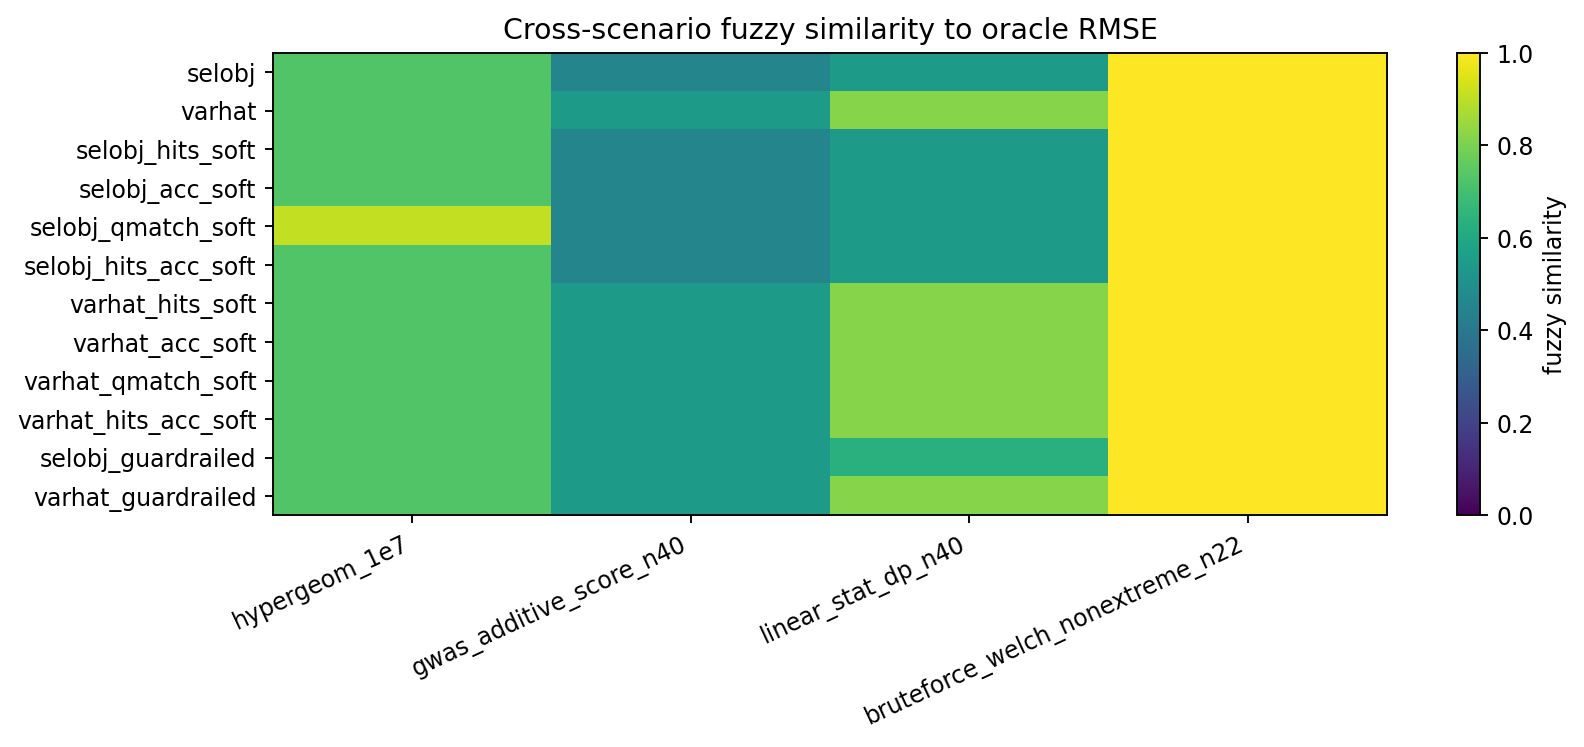

In [7]:
cross_scenario_df = pd.DataFrame(cross_scenario_objective_rows)
realistic_cross_scenario_df = cross_scenario_df[cross_scenario_df["objective_kind"] == "realistic"].copy()
leaderboard_df = build_cross_scenario_leaderboard(cross_scenario_objective_rows)
display(leaderboard_df)
display(realistic_cross_scenario_df.sort_values(["objective_name", "scenario_key"])[[
    "scenario_key",
    "objective_name",
    "config_id",
    "q_multiplier",
    "n_swap_pairs",
    "beta",
    "oracle_exact_match",
    "oracle_fuzzy_similarity",
    "oracle_q_index_distance",
    "oracle_swap_distance",
]])

if SAVE_OUTPUTS and run_dir is not None:
    plot_cross_scenario_fuzzy_similarity(
        cross_scenario_objective_rows,
        save_path=run_dir / "cross_scenario_fuzzy_similarity_heatmap.png",
    )
    display(Image(filename=str(run_dir / "cross_scenario_fuzzy_similarity_heatmap.png")))
else:
    plot_cross_scenario_fuzzy_similarity(cross_scenario_objective_rows)
    print("SAVE_OUTPUTS=False, so the cross-scenario heatmap was not saved.")

## Review Saved Figures

Saved outputs under: /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/mcmcis_objective_grid/20260312_194143_objective_grid

hypergeom_1e7


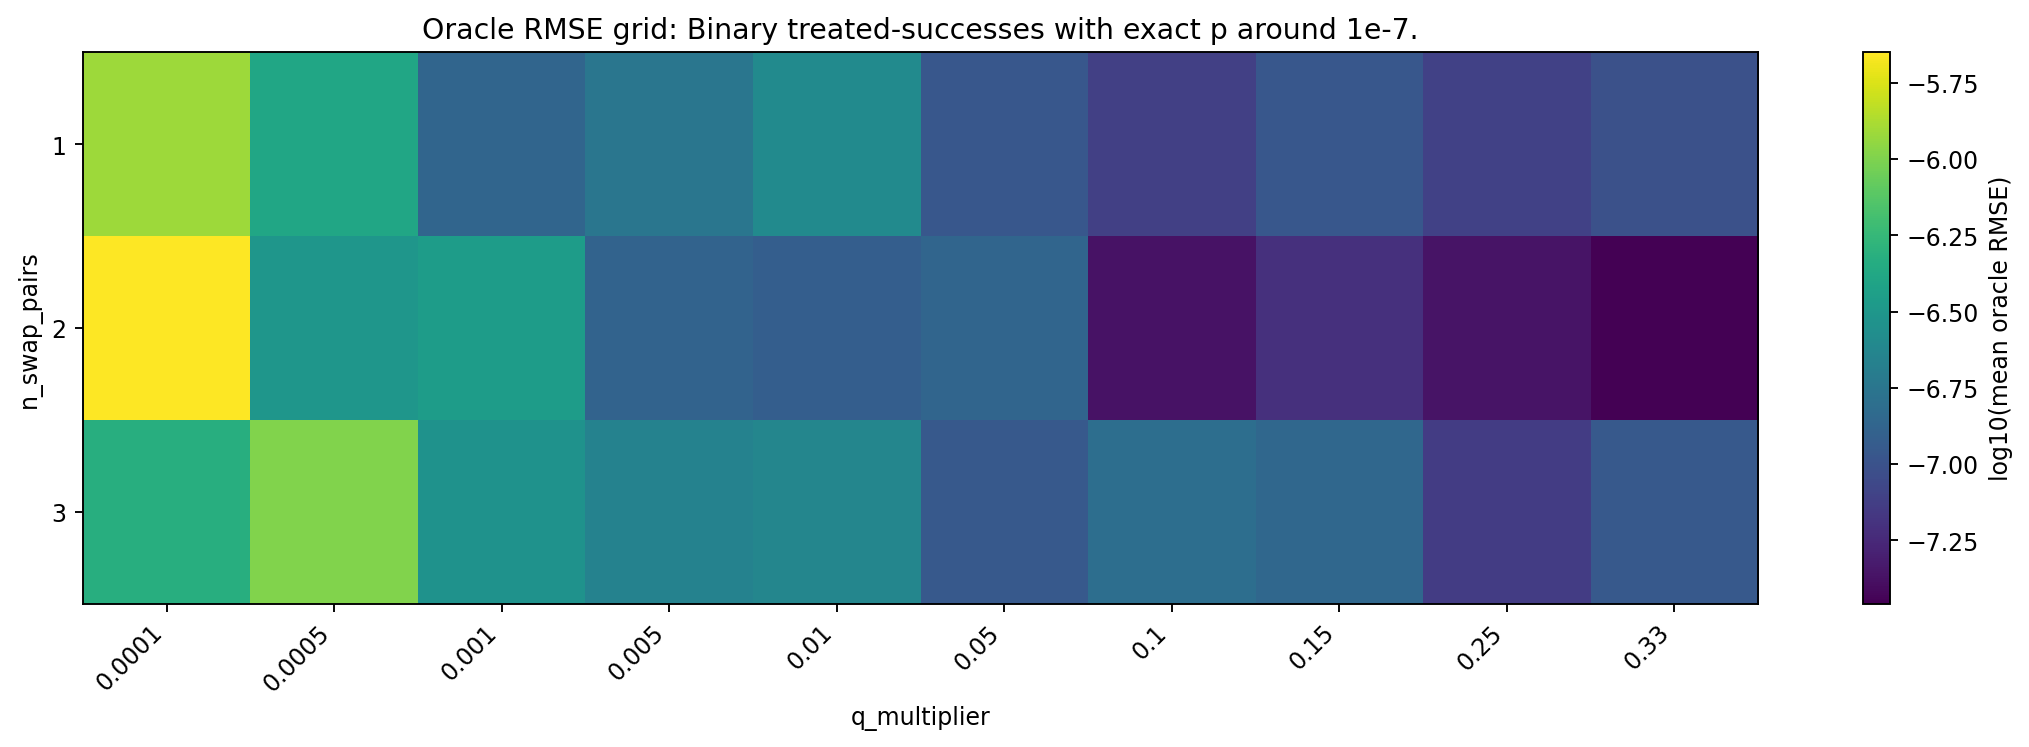

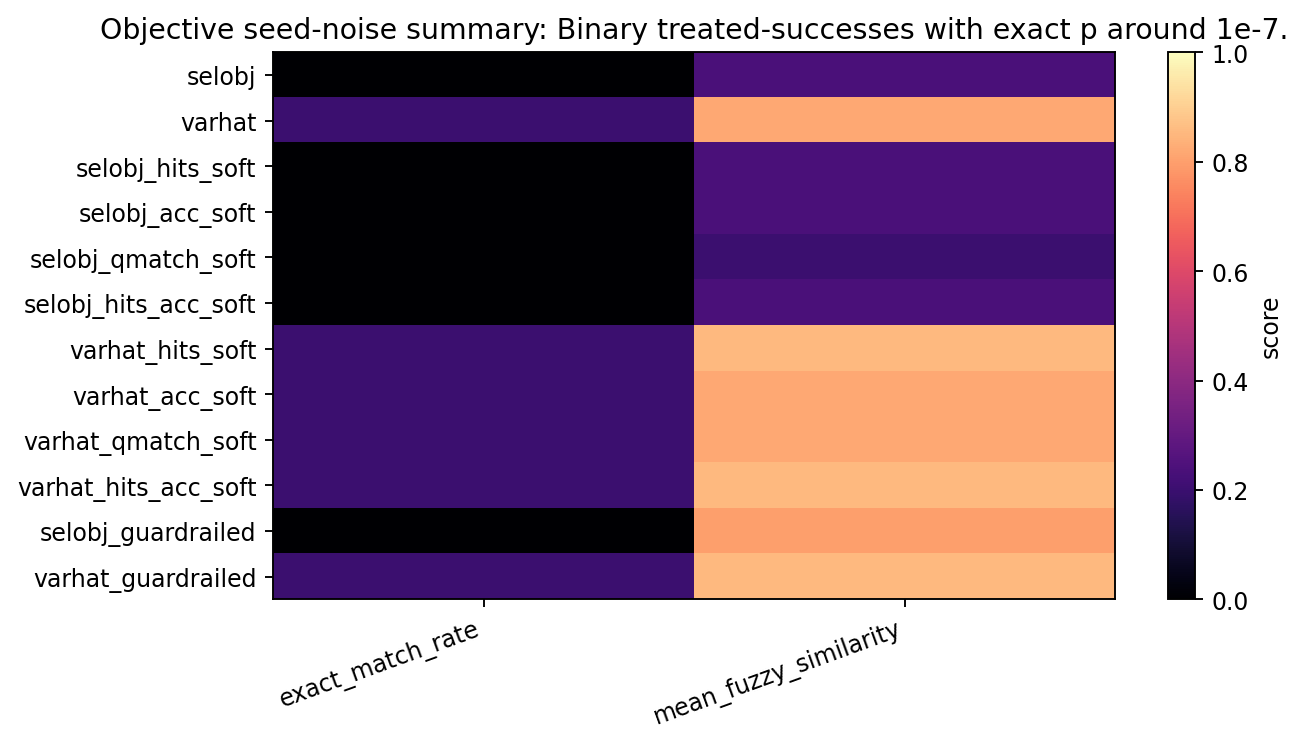


gwas_additive_score_n40


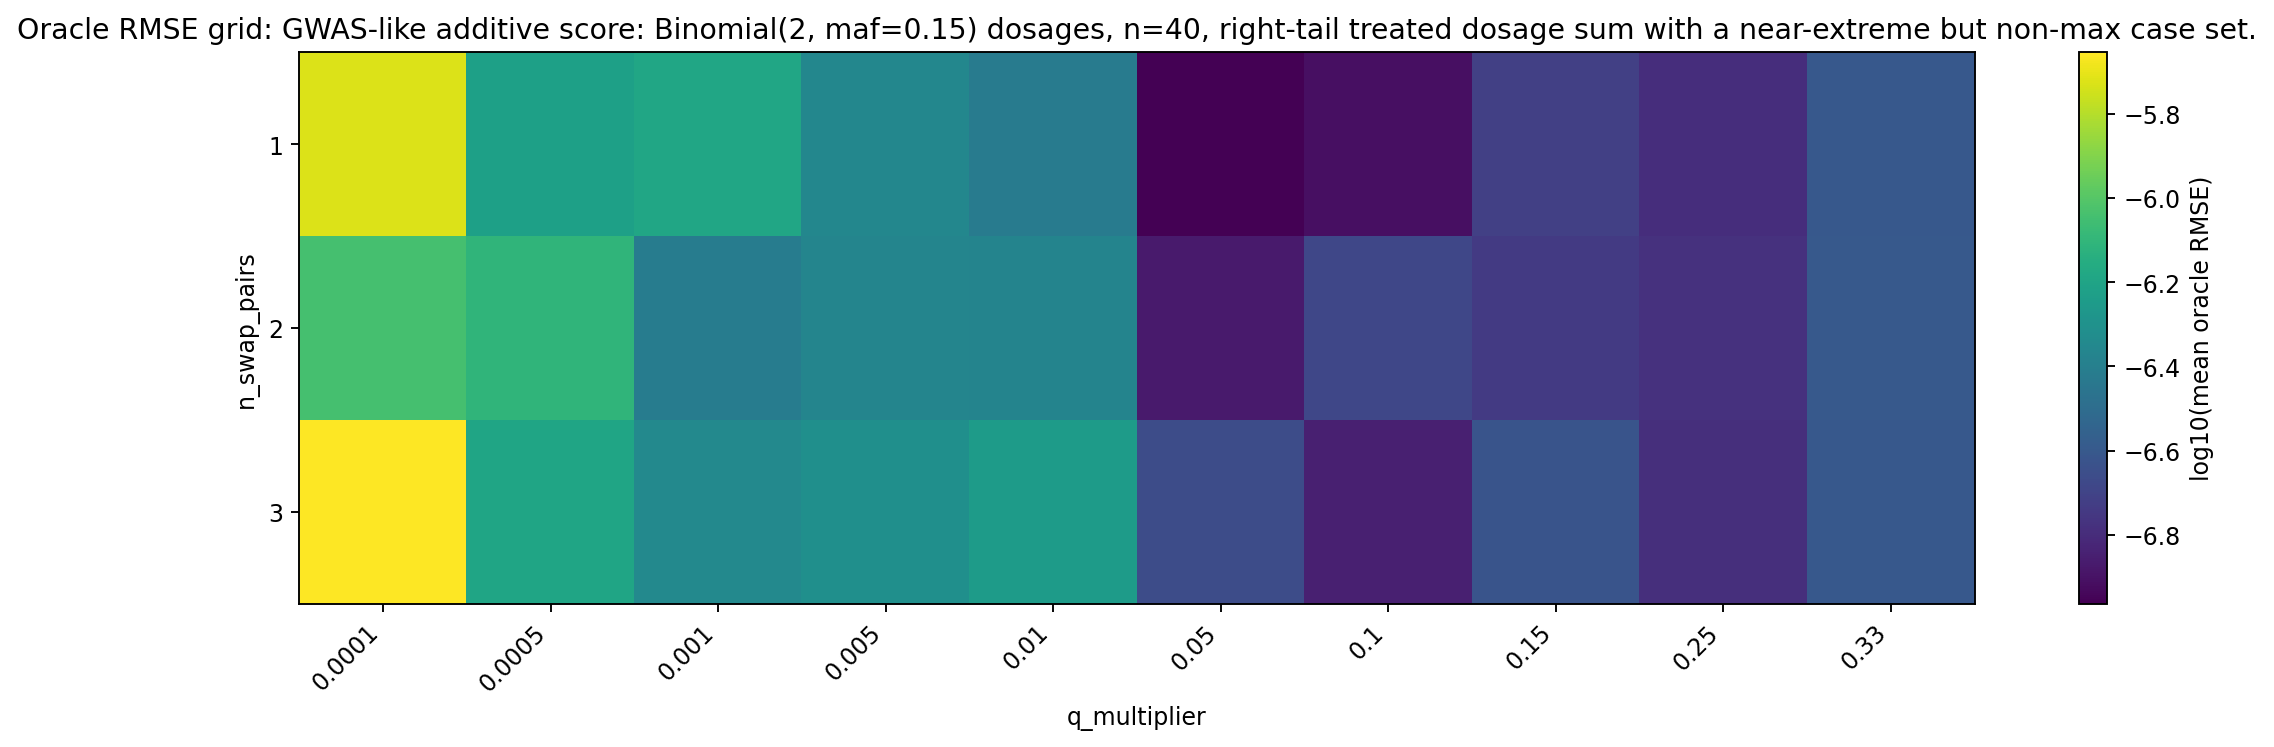

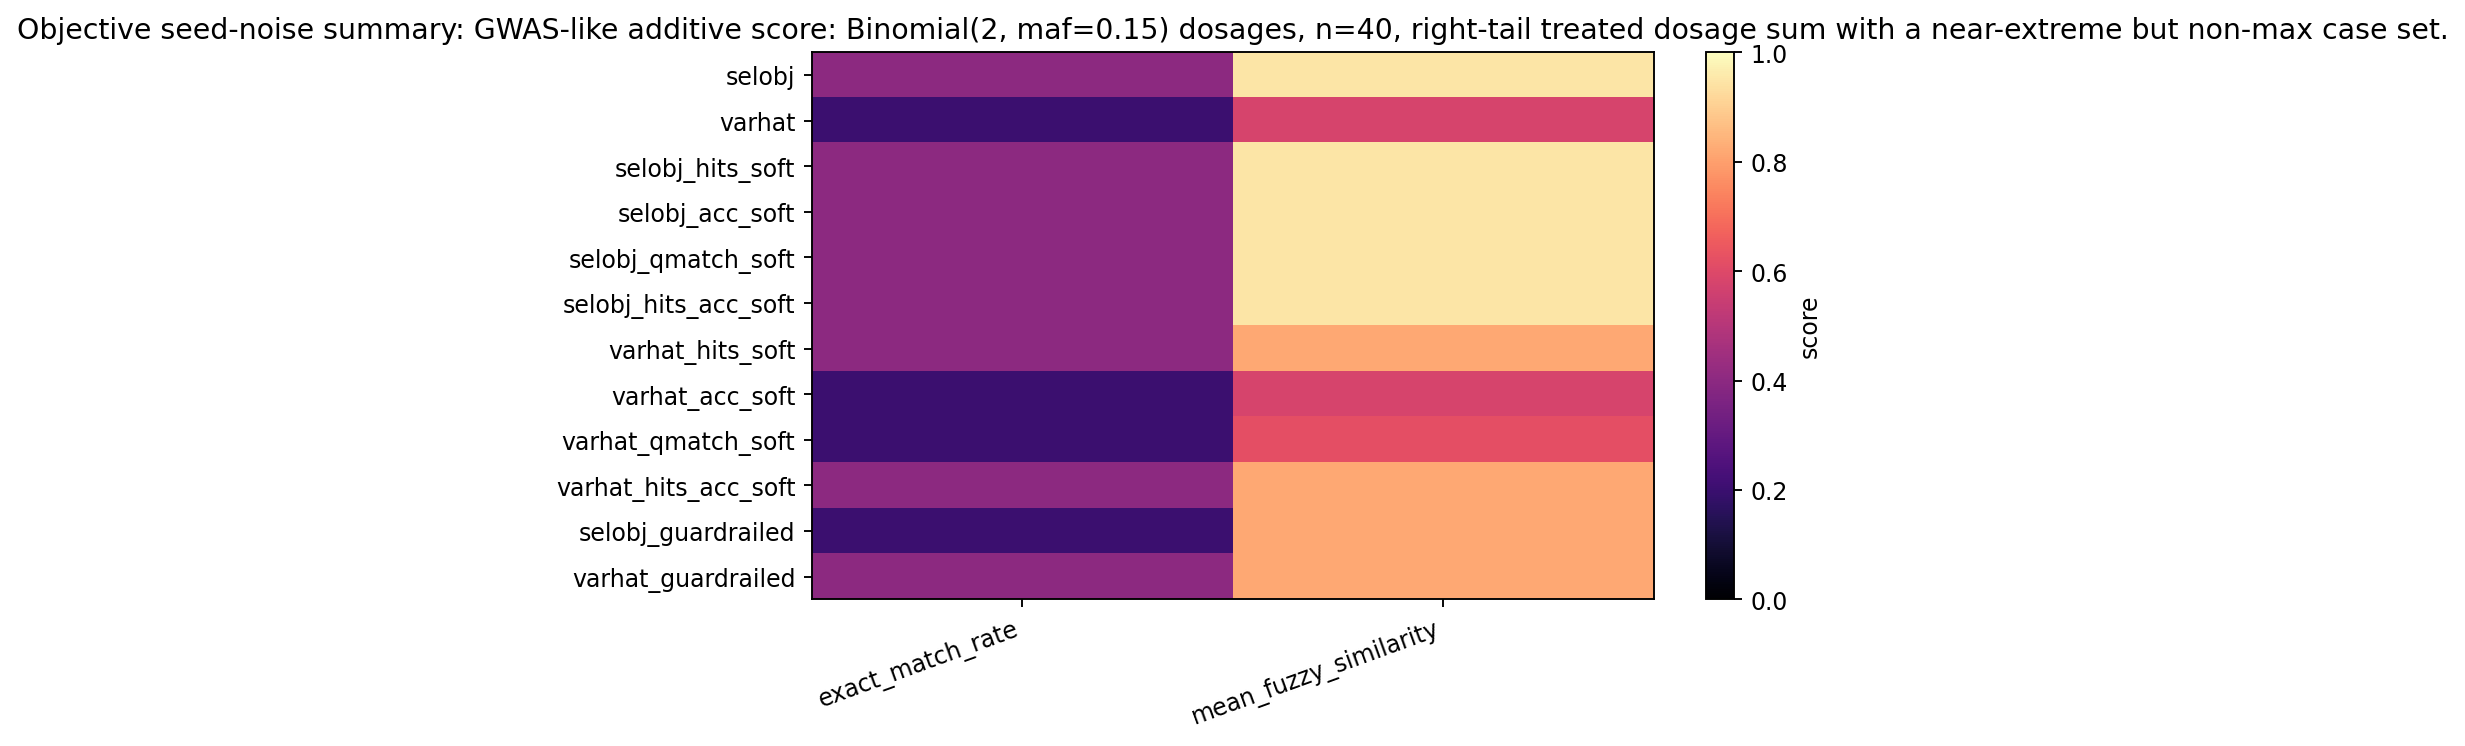


linear_stat_dp_n40


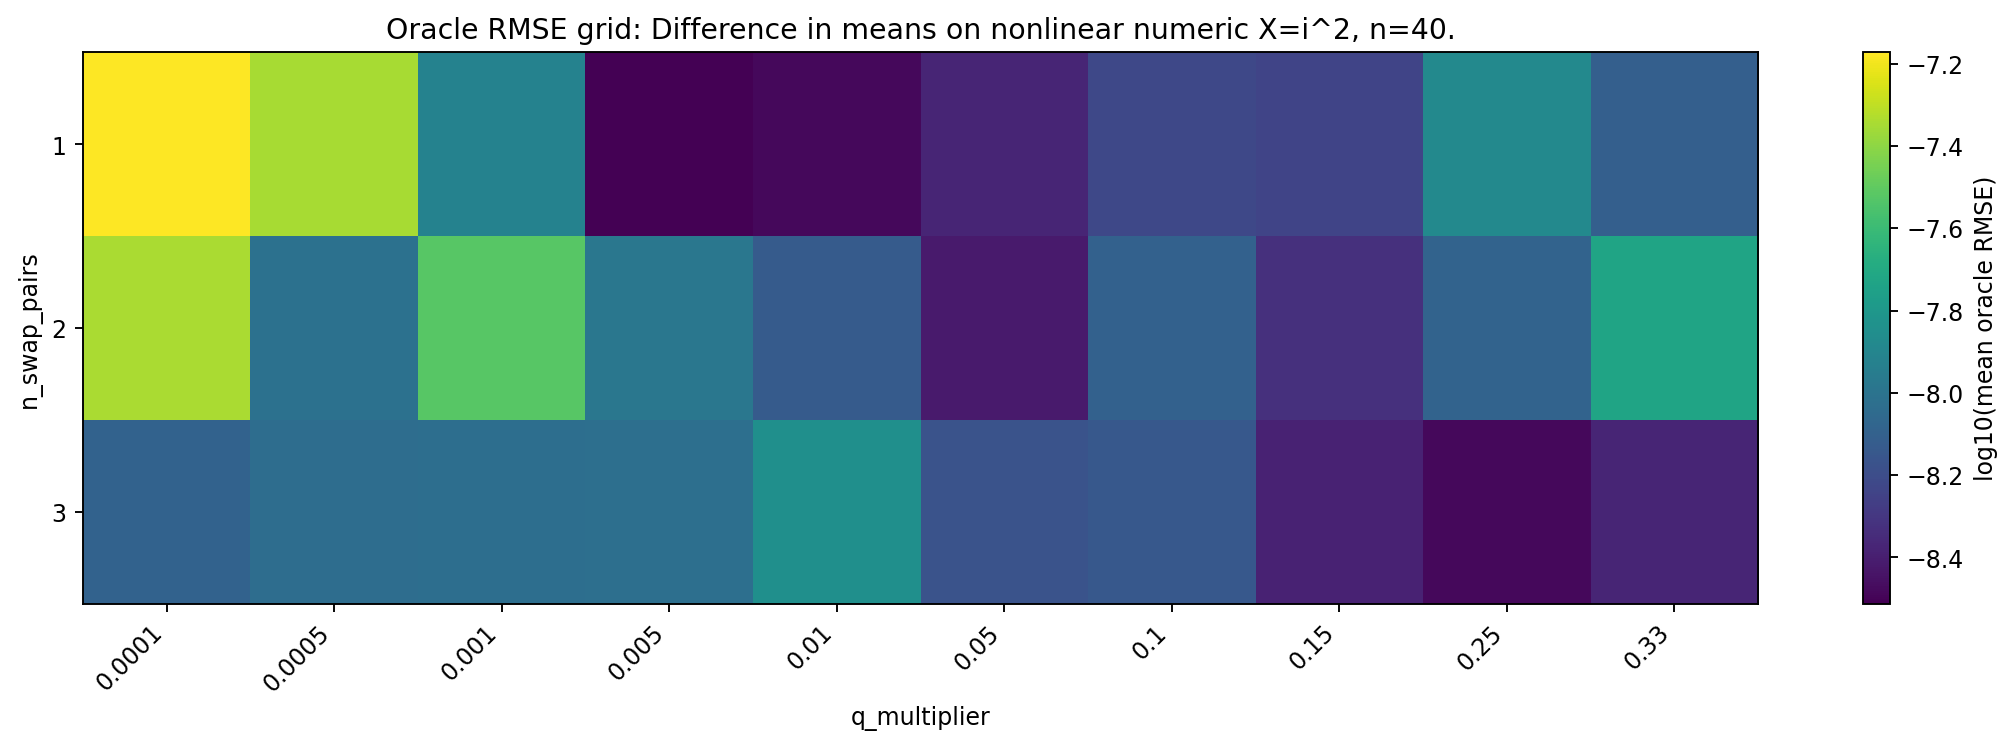

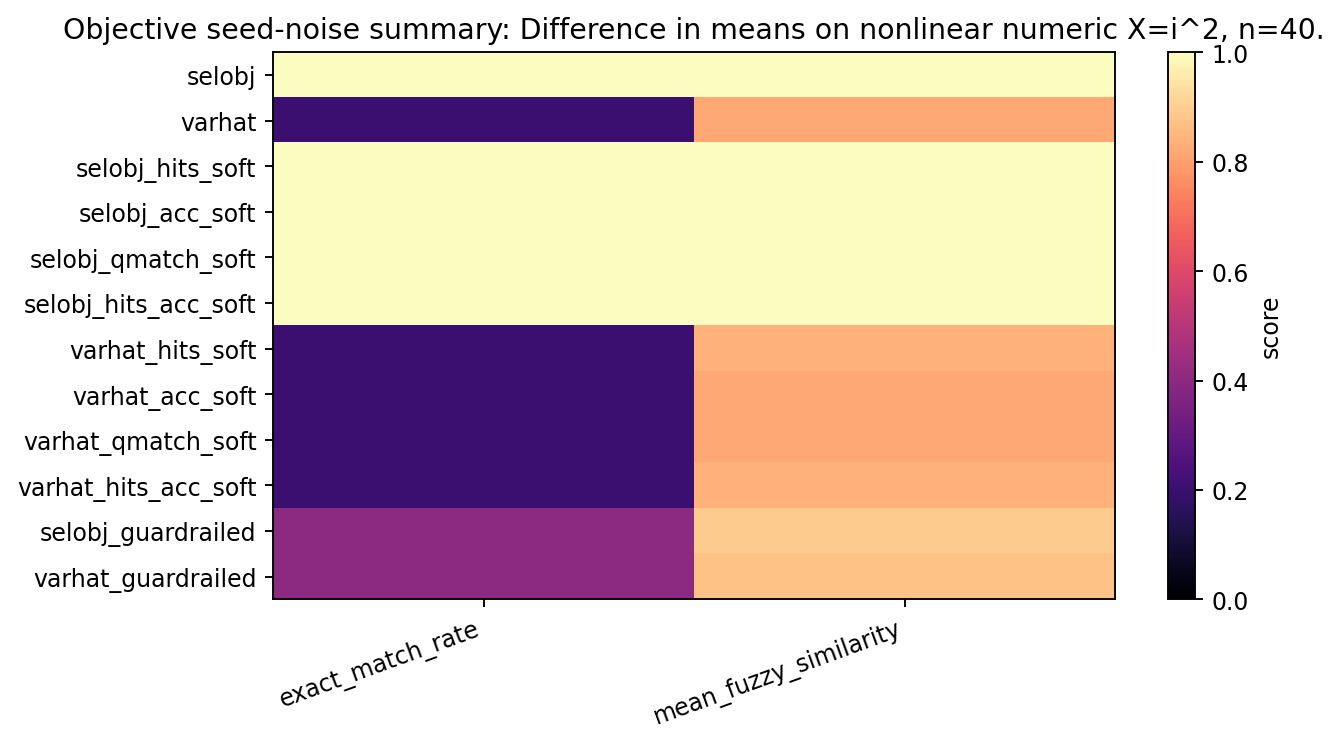


bruteforce_welch_nonextreme_n22


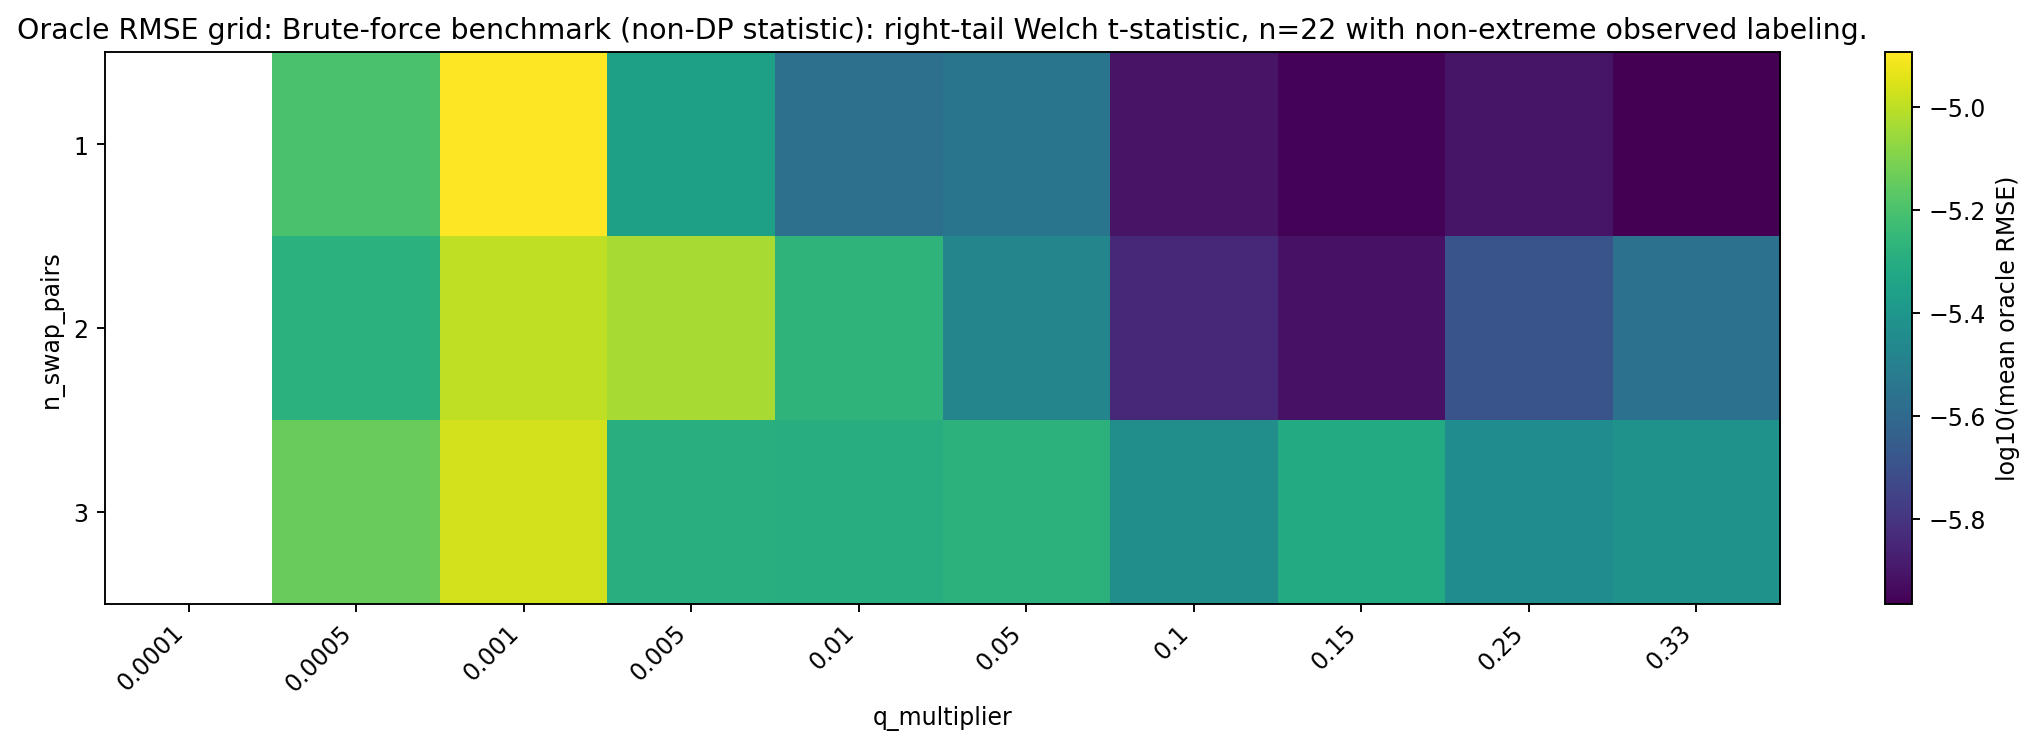

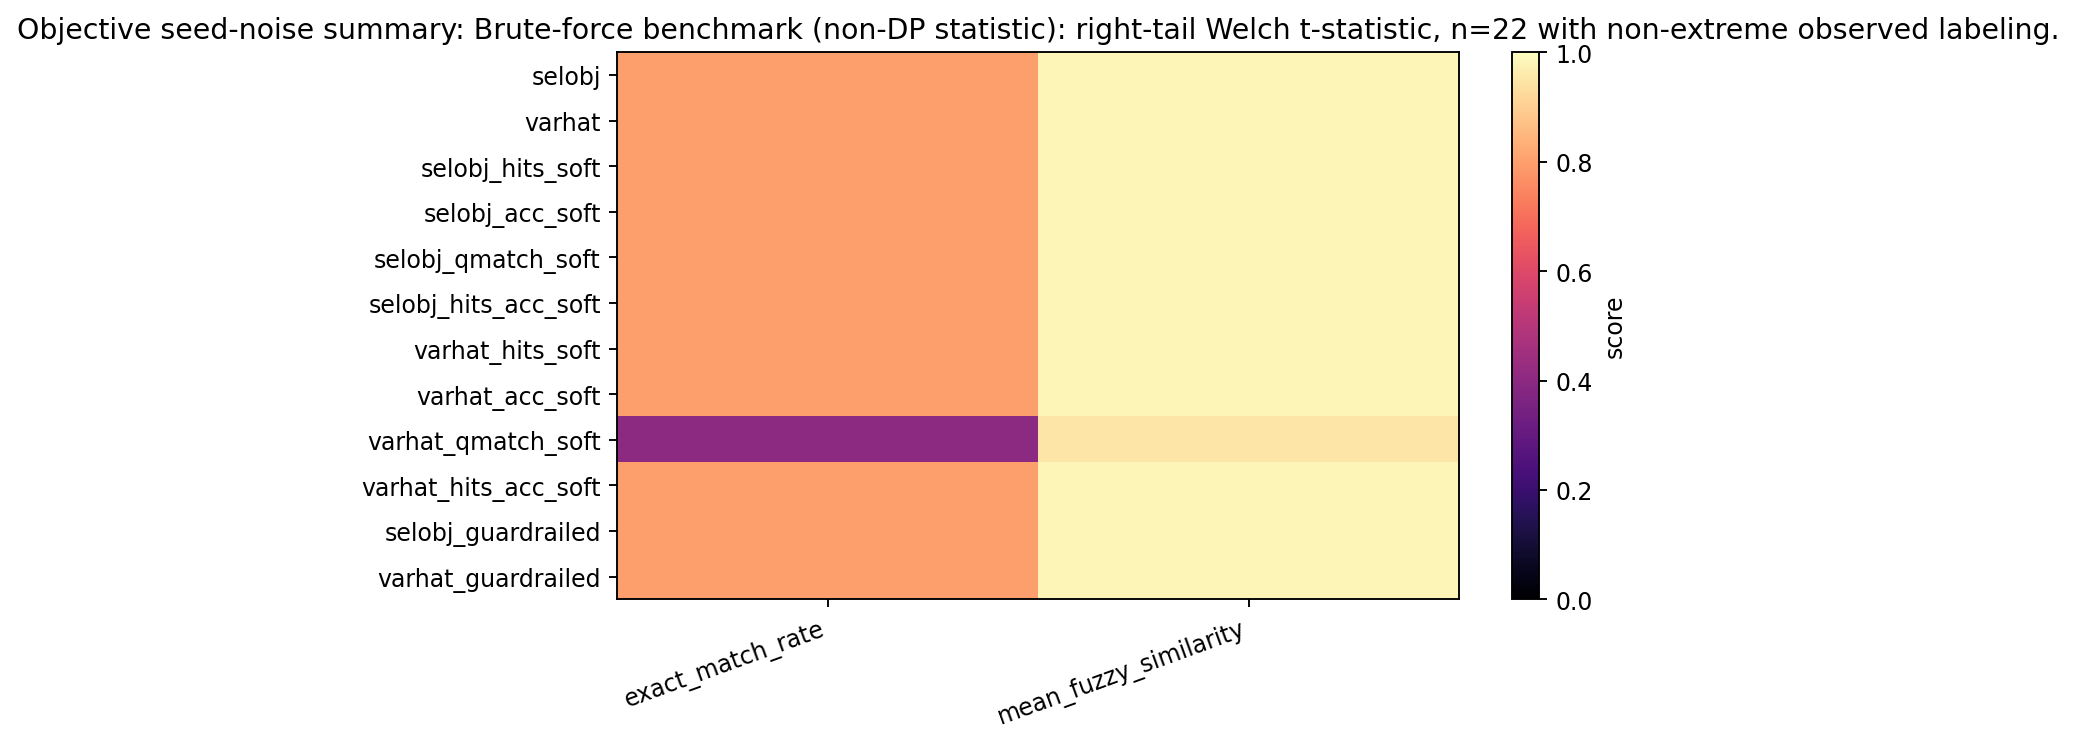

In [8]:
if SAVE_OUTPUTS and run_dir is not None:
    print(f"Saved outputs under: {run_dir}")
    for scenario in scenarios:
        scenario_dir = run_dir / scenario.key
        print(f"\n{scenario.key}")
        display(Image(filename=str(scenario_dir / "oracle_rmse_heatmap.png")))
        display(Image(filename=str(scenario_dir / "objective_seed_noise_heatmap.png")))
else:
    print("SAVE_OUTPUTS=False, so no saved figures to display.")

## Reload Saved Results Without Rerunning

In [ ]:
# RELOAD_GRID_DIR = None
# # Example:
# # RELOAD_GRID_DIR = project_root / "results" / "mcmcis_objective_grid" / "20260312_120000_objective_grid" / "linear_stat_dp_n40"

# if RELOAD_GRID_DIR is not None:
#     saved = load_mcmc_objective_grid_saved_output(RELOAD_GRID_DIR)
#     print(json.dumps({
#         "scenario_display": saved["config_summary_payload"]["scenario_display"],
#         "exact_p": saved["config_summary_payload"]["exact_p"],
#     }, indent=2))
#     display(pd.DataFrame(saved["config_summary_payload"]["config_summary"]).head())
#     display(pd.DataFrame(saved["objective_winners_payload"]["objective_winners"]).head())
#     display(pd.DataFrame(saved["objective_seed_noise_payload"]["objective_seed_noise"]).head())
# else:
#     print("Set RELOAD_GRID_DIR to a saved objective-grid scenario directory to inspect saved results.")